In [1]:
# !pip install -r requirements.txt -qqq

## Problem Statement: Loan Approval Prediction 

The company seeks **to automate (in real time) the loan qualifying procedure** based on information given by customers while filling out an online application form. It is expected that the development of ML models that can help the company predict loan approval in accelerating decision-making process for determining whether an applicant is eligible for a loan or not.

# 1. Evaluation metrics and threshold

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## load the data

In [3]:
# load the train/test data
X_train = pd.read_csv("data/X_train.csv")
y_train = pd.read_csv("data/y_train.csv").squeeze()  # squeeze() converts the dataframe to a Series
X_test = pd.read_csv("data/X_test.csv")
y_test = pd.read_csv("data/y_test.csv").squeeze()   

In [4]:
X_train.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,2,2045,1619,101,360,1,True,True,False,False,False,False
1,0,4100,0,124,360,1,False,True,True,False,False,False
2,0,2083,4083,160,360,1,False,True,False,True,True,False
3,1,2661,7101,279,180,1,True,True,True,False,True,False
4,0,4583,0,112,360,1,False,True,False,False,False,False


In [5]:
y_train.head()

0     True
1     True
2     True
3     True
4    False
Name: Loan_Status_Y, dtype: bool

In [6]:
print(X_train.shape)

(414, 12)


In [7]:
print(X_test.shape)

(100, 12)


In [8]:
y_train.value_counts()

Loan_Status_Y
True     281
False    133
Name: count, dtype: int64

In [9]:
y_test.value_counts()

Loan_Status_Y
True     70
False    30
Name: count, dtype: int64

## logistic regression model

In [10]:
# train a logistic regression model, and predict on the test set (X_test)
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1] 

## fixed threshold

In [11]:
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)    

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Threshold: {threshold:.4f} | Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

              precision    recall  f1-score   support

       False       0.95      0.70      0.81        30
        True       0.88      0.99      0.93        70

    accuracy                           0.90       100
   macro avg       0.92      0.84      0.87       100
weighted avg       0.91      0.90      0.90       100

[[21  9]
 [ 1 69]]
Threshold: 0.5000 | Accuracy: 0.9000 | Precision: 0.8846 | Recall: 0.9857 | F1: 0.9324


## all possible thresholds

In [12]:
# iterate over all unique values in y_proba as possible thresholds, 
# compute metrics, and save the results to a DataFrame.
metrics_list = []
thresholds = np.sort(np.unique(y_proba))

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    metrics_list.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

metrics_df = pd.DataFrame(metrics_list)

In [13]:
metrics_df.head()

,threshold,accuracy,precision,recall,f1
0,0.057938,0.70,0.700000,1.0,0.823529
1,0.064382,0.71,0.707071,1.0,0.828402
2,0.065637,0.72,0.714286,1.0,0.833333
3,0.088750,0.73,0.721649,1.0,0.838323
4,0.089475,0.74,0.729167,1.0,0.843373


<Axes: xlabel='threshold'>

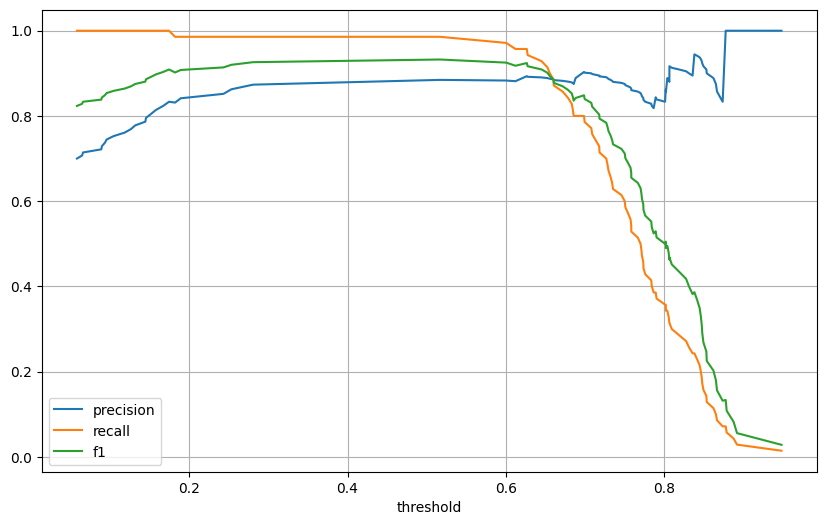

In [14]:
metrics_df.plot(x="threshold", y=["precision", "recall", "f1"], figsize=(10, 6), grid=True)

## threshold with the highest f1 score

In [15]:
# results with the highest f1 score
best_f1 = metrics_df.loc[metrics_df['f1'].idxmax()]
print(best_f1)

threshold    0.516868
accuracy     0.900000
precision    0.884615
recall       0.985714
f1           0.932432
Name: 22, dtype: float64


## tradeoff between precision and total LoanAmount

In [16]:
# add a new column to metrics_df, showing the total LoanAmount for predicted positives
loan_sums = []

for threshold in metrics_df['threshold']:
    y_pred = (y_proba >= threshold).astype(int)
    loan_sum = X_test.loc[y_pred == 1, "LoanAmount"].sum()
    loan_sums.append(loan_sum)

metrics_df['loan_sum'] = loan_sums

metrics_df.head()

,threshold,accuracy,precision,recall,f1,loan_sum
0,0.057938,0.70,0.700000,1.0,0.823529,14646
1,0.064382,0.71,0.707071,1.0,0.828402,14566
2,0.065637,0.72,0.714286,1.0,0.833333,14348
3,0.088750,0.73,0.721649,1.0,0.838323,14222
4,0.089475,0.74,0.729167,1.0,0.843373,14110


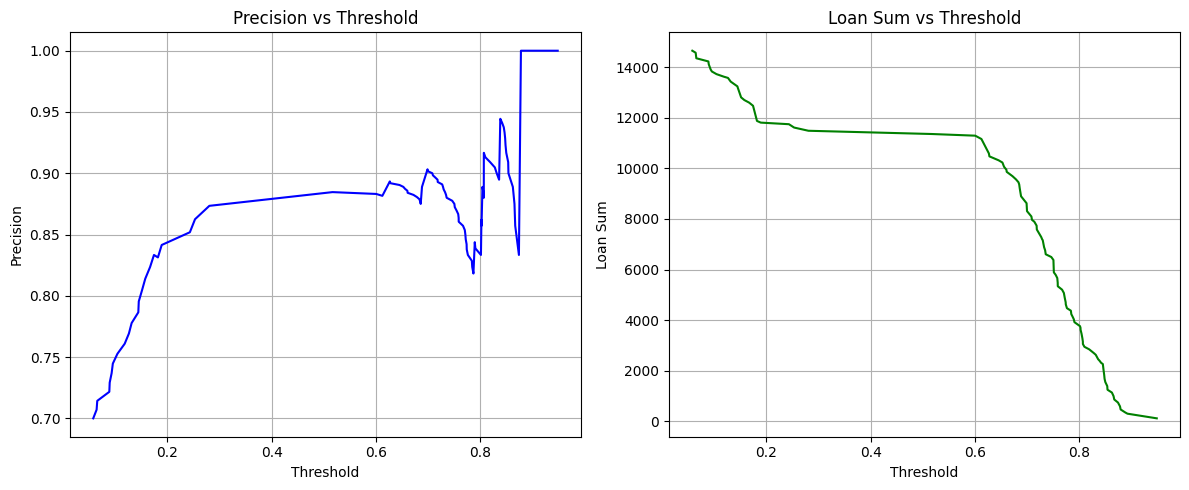

In [17]:
# plot precision vs threshold, and total loan_Amount vs threshold

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Precision vs Threshold
axs[0].plot(metrics_df['threshold'], metrics_df['precision'], color='blue')
axs[0].set_title('Precision vs Threshold')
axs[0].set_xlabel('Threshold')
axs[0].set_ylabel('Precision')
axs[0].grid(True)

# Plot Loan Sum vs Threshold
axs[1].plot(metrics_df['threshold'], metrics_df['loan_sum'], color='green')
axs[1].set_title('Loan Sum vs Threshold')
axs[1].set_xlabel('Threshold')
axs[1].set_ylabel('Loan Sum')
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
# higher threshold generally leads to higher precision, while lower total loan_Amount
# we cannot maximise precision and loan_sum simultaneously

# approach 1: maximise loan_sum with a constraint that precision is at least, say 0.9
filtered_df = metrics_df[metrics_df['precision'] >= 0.9]
best_row = filtered_df.loc[filtered_df['loan_sum'].idxmax()]
print(best_row)

threshold       0.698951
accuracy        0.800000
precision       0.903226
recall          0.800000
f1              0.848485
loan_sum     8619.000000
Name: 38, dtype: float64


In [19]:
# approach 2: maximise precision with a constraint that loan_sum is at least, say 12,000
filtered_df = metrics_df[metrics_df['loan_sum'] >= 12000]
best_row = filtered_df.loc[filtered_df['precision'].idxmax()]
print(best_row)

threshold        0.174382
accuracy         0.860000
precision        0.833333
recall           1.000000
f1               0.909091
loan_sum     12471.000000
Name: 16, dtype: float64


# 2. Explainability

## a simple decision tree

In [20]:
# a simple decision tree model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=2, random_state=2025)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2025
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


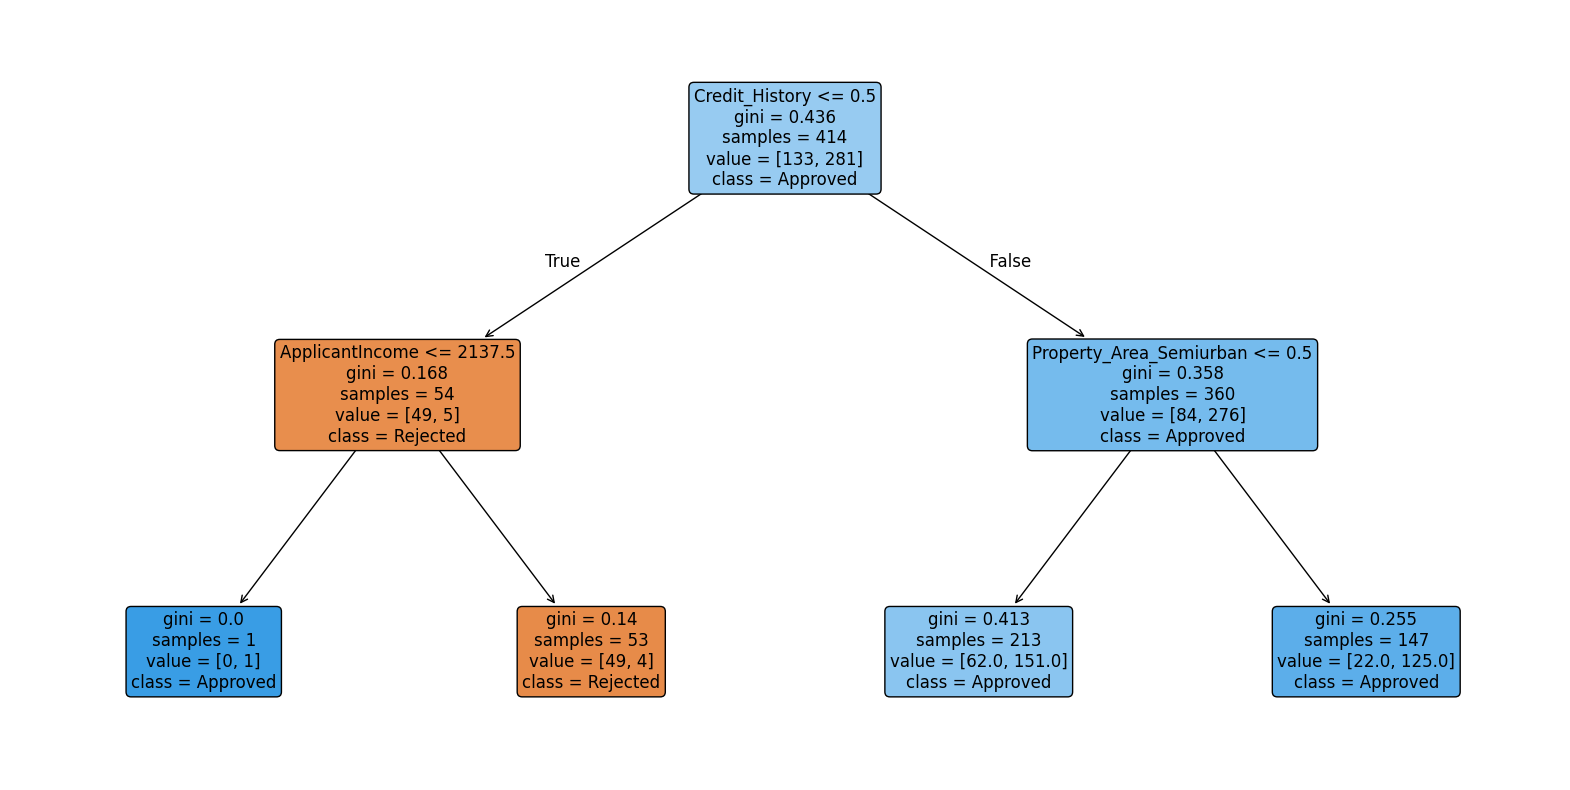

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train.columns, 
          class_names=['Rejected', 'Approved'],  
          filled=True, 
          rounded=True,
          fontsize=12)
plt.show()

## a random forest model 

In [22]:
# a random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=2025)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.78      0.70      0.74        30
        True       0.88      0.91      0.90        70

    accuracy                           0.85       100
   macro avg       0.83      0.81      0.82       100
weighted avg       0.85      0.85      0.85       100



## LIME for the rf model

In [23]:
# explain one prediction using LIME
import lime
import lime.lime_tabular

from IPython.display import HTML

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names = ['Rejected', 'Approved'],
    mode='classification'
)

i = 3  # index of the sample in X_test
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba
)

HTML(exp.as_html())

/home/yjiah/dsa3101/.venv/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/yjiah/dsa3101/.venv/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/yjiah/dsa3101/.venv/lib/python3.12/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavi

## SHAP for the rf model

In [24]:
# explain one prediction using SHAP value
import shap

shap_explainer = shap.TreeExplainer(rf_model)
shap_values = shap_explainer.shap_values(X_test)

shap.initjs()
shap.force_plot(shap_explainer.expected_value[1], shap_values[i,:,1], X_test.iloc[i])

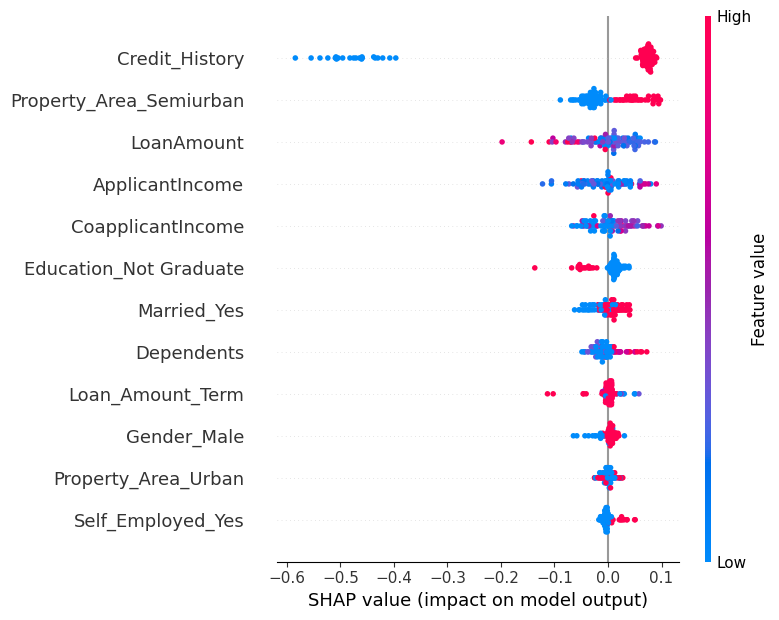

In [25]:
# summary plot explaining predictions for class 1 (positive class)
shap.summary_plot(shap_values[:,:,1], X_test)

# 3. Drift detection

## Model performance degradation

In [26]:
# Recall the logistic regression model with highest f1 score
print(best_f1)

threshold    0.516868
accuracy     0.900000
precision    0.884615
recall       0.985714
f1           0.932432
Name: 22, dtype: float64


In [27]:
# use that threshold to predict on a new test set
threshold_best = best_f1['threshold']

X_test2 = pd.read_csv("data/X_test2.csv")
y_test2 = pd.read_csv("data/y_test2.csv").squeeze()  
y_proba2 = model.predict_proba(X_test2)[:, 1] 
y_pred2 = (y_proba2 >= threshold_best).astype(int)

print(classification_report(y_test2, y_pred2))

              precision    recall  f1-score   support

       False       0.87      0.45      0.59        29
        True       0.81      0.97      0.88        71

    accuracy                           0.82       100
   macro avg       0.84      0.71      0.74       100
weighted avg       0.83      0.82      0.80       100



In [28]:
# the results on the original test dataset
y_pred = (y_proba >= threshold_best).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.95      0.70      0.81        30
        True       0.88      0.99      0.93        70

    accuracy                           0.90       100
   macro avg       0.92      0.84      0.87       100
weighted avg       0.91      0.90      0.90       100



## PSI analysis

In [29]:
# a helper function to calculate the PSI for a single numeric variable
def calculate_psi(baseline, target, buckets=10):
    breakpoints = np.percentile(baseline, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)  # remove duplicates (in case of constant values)
    baseline_bins = pd.cut(baseline, bins=breakpoints, include_lowest=True)
    target_bins = pd.cut(target, bins=breakpoints, include_lowest=True)

    baseline_distr = baseline_bins.value_counts(normalize=True).sort_index()
    target_distr = target_bins.value_counts(normalize=True).sort_index()

    psi_df = pd.DataFrame({
        'baseline': baseline_distr,
        'target': target_distr
    }).fillna(0.0001)  # to avoid div by 0 or log(0)

    psi_df['psi'] = (psi_df['target'] - psi_df['baseline']) * np.log(psi_df['target'] / psi_df['baseline'])
    psi_total = psi_df['psi'].sum()

    return psi_total

In [30]:
# calculate PSI for 'LoadAmount' between X_test and X_test2
psi_loanamount = calculate_psi(X_test['LoanAmount'], X_test2['LoanAmount'])
print(f"PSI: {psi_loanamount:.4f}")

PSI: 0.1828


In [31]:
# calculate PSI for 'ApplicantIncome' between X_test and X_test2
psi_applicantincome = calculate_psi(X_test['ApplicantIncome'], X_test2['ApplicantIncome'])
print(f"PSI: {psi_applicantincome:.4f}")

PSI: 0.4426


In [32]:
# calculate PSI for numeric variables between X_test and X_test2
columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
psi_results = {}

for col in columns:
    psi = calculate_psi(X_test[col], X_test2[col])
    psi_results[col] = psi

psi_df = pd.DataFrame.from_dict(psi_results, orient='index', columns=['PSI'])
psi_df = psi_df.sort_values('PSI', ascending=False)
print(psi_df)

                        PSI
ApplicantIncome    0.442647
CoapplicantIncome  0.201372
LoanAmount         0.182787
Loan_Amount_Term   0.047150


## KS test

In [33]:
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(X_test['Loan_Amount_Term'], X_test2['Loan_Amount_Term'])

print(f"KS Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

KS Statistic: 0.0300
P-value: 1.0000


In [34]:
ks_results = {}

for col in columns:
    stat, p_value = ks_2samp(X_test[col], X_test2[col])
    ks_results[col] = {
        'KS Statistic': stat,
        'p-value': p_value
    }

ks_df = pd.DataFrame(ks_results).T.sort_values('KS Statistic', ascending=False)
print(ks_df)

                   KS Statistic       p-value
ApplicantIncome            0.41  6.617358e-08
CoapplicantIncome          0.19  5.390208e-02
LoanAmount                 0.14  2.819416e-01
Loan_Amount_Term           0.03  1.000000e+00
